In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import re

from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon

In [2]:
df = pd.read_csv('resultados.csv')

# **Estatiscas basicas**

In [3]:
def tabela_relatorio(df):
  resumo = (
      df.groupby('algo')
      .agg(
          gap_media=('gap', 'mean'),
          gap_dp=('gap', 'std'),
          gap_mediana=('gap', 'median'),
          gap_min=('gap', 'min'),
          gap_max=('gap', 'max'),

          tempo_melhor_media=('tempo_melhor', 'mean'),
          tempo_melhor_dp=('tempo_melhor', 'std'),

          tempo_total_media=('tempo_total', 'mean'),
          tempo_total_dp=('tempo_total', 'std'),

          n=('gap', 'count')
      )
      .sort_values('gap_media')
  )

  return resumo.round(4)

resumo = tabela_relatorio(df)
display(resumo)
df_resumo = resumo.to_csv('resumo.csv')

,gap_media,gap_dp,gap_mediana,gap_min,gap_max,tempo_melhor_media,tempo_melhor_dp,tempo_total_media,tempo_total_dp,n
algo,,,,,,,,,,
vns,0.0052,0.0303,0.0,0.0,0.2555,24.9419,61.7581,34.8767,88.7357,1500
ils,0.0062,0.0354,0.0,0.0,0.3451,17.7193,49.7335,30.7492,86.0960,1500
ga,0.0095,0.0516,0.0,0.0,0.6807,16.4996,43.6720,33.5442,91.1340,1500
lns,0.0233,0.0868,0.0,0.0,0.7371,34.5072,79.2725,62.0363,129.7138,1500
brkga,0.0254,0.1089,0.0,0.0,1.3877,30.0250,64.3967,59.0458,120.4144,1500
sa,0.0376,0.1017,0.0,0.0,0.9643,54.4540,92.5898,101.7211,156.6299,1500
grasp,0.0390,0.1145,0.0,0.0,0.9279,56.7892,98.1839,95.5523,153.6716,1500
pso,0.1056,0.3372,0.0,0.0,4.0763,55.6825,96.9309,124.7755,175.6267,1500


In [4]:
def percentual_melhor(df):
  melhores = (
      df.groupby(['instancia', 'seed'])['gap']
        .transform('min')
  )

  venceu = df['gap'] == melhores

  ranking = (
      df.assign(venceu=venceu)
        .groupby('algo')['venceu']
        .mean()
        .mul(100)
        .sort_values(ascending=False)
        .rename('%_melhor')
  )

  return ranking.round(2)

display(percentual_melhor(df))

,%_melhor
algo,
vns,96.60
ils,96.53
ga,95.73
brkga,91.27
lns,89.93
grasp,83.00
sa,81.67
pso,73.13


In [5]:
def tabela_por_instancia(df):
  resumo = (
      df.groupby(['instancia', 'algo'])
      .agg(
          gap_media=('gap', 'mean'),
          gap_dp=('gap', 'std'),
          gap_mediana=('gap', 'median'),
          gap_min=('gap', 'min'),
          gap_max=('gap', 'max'),

          otimos_encontrados=('gap', lambda x: (x == 0).sum()),
          taxa_otimo=('gap', lambda x: (x == 0).mean() * 100),

          tempo_melhor_media=('tempo_melhor', 'mean'),
          tempo_melhor_dp=('tempo_melhor', 'std'),

          tempo_total_media=('tempo_total', 'mean'),
          tempo_total_dp=('tempo_total', 'std'),

          n=('gap', 'count')
      )
      .reset_index()
      .sort_values(['instancia', 'gap_media'])
  )

  return resumo.round(4)

resumo_instancias = tabela_por_instancia(df)
display(resumo_instancias)
df_instancias = resumo_instancias.to_csv('resultados_instacias.csv')

,instancia,algo,gap_media,gap_dp,gap_mediana,gap_min,gap_max,otimos_encontrados,taxa_otimo,tempo_melhor_media,tempo_melhor_dp,tempo_total_media,tempo_total_dp,n
0,A-n32-k5,brkga,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0941,0.0080,0.1606,0.0109,30
1,A-n32-k5,ga,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0421,0.0337,0.0743,0.0104,30
2,A-n32-k5,grasp,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0116,0.0118,0.0116,0.0119,30
3,A-n32-k5,ils,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.0442,0.0363,0.0442,0.0363,30
4,A-n32-k5,lns,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,0.1069,0.1055,0.1069,0.1055,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,B-n78-k10,vns,0.0000,0.0000,0.0000,0.0000,0.0000,30,100.0000,10.6102,5.5254,10.6102,5.5254,30
398,B-n78-k10,sa,0.0546,0.0785,0.0000,0.0000,0.1638,20,66.6667,168.7326,103.5614,257.5757,131.3107,30
394,B-n78-k10,grasp,0.0628,0.0669,0.0819,0.0000,0.1638,14,46.6667,190.7135,85.7696,306.2919,120.5779,30
396,B-n78-k10,lns,0.1665,0.2046,0.1638,0.0000,0.7371,12,40.0000,204.1735,134.2963,323.6955,123.4887,30


# **Performance Profile**

In [6]:
def preparar_matriz_profile(df, metrica, agregacao='mean'):
  df_agg = (
      df.groupby(['instancia', 'algo'])
        .agg(valor=(metrica, agregacao))
        .reset_index()
  )

  matriz = df_agg.pivot(
      index='instancia',
      columns='algo',
      values='valor'
  )

  return matriz

def plot_performance_profile(matriz, titulo):
  data = matriz.apply(pd.to_numeric, errors='coerce')
  data = data.fillna(np.inf)

  melhor = data.min(axis=1)

  # evita divisão por zero quando todos gap 0
  melhor = melhor.replace(0, 1e-12)

  razao = data.divide(melhor, axis=0)

  n_instancias = len(data)

  max_tau = razao.replace(np.inf, np.nan).max().max()

  if np.isnan(max_tau) or max_tau <= 1:
      max_tau = 2

  taus = np.linspace(1, max_tau, 1000)

  plt.figure(figsize=(11, 6))

  for algo in razao.columns:
      y = [(razao[algo] <= tau).sum() / n_instancias for tau in taus]
      plt.step(taus, y, where='post', lw=2, label=algo)

  plt.xscale('log', base=2)
  plt.xlabel(r'Razão de desempenho $\tau$')
  plt.ylabel('Fração de instâncias')
  plt.title(titulo)
  plt.grid(True, which='both', ls='--', alpha=0.5)
  plt.legend()
  plt.ylim(0, 1.05)
  plt.tight_layout()
  plt.show()

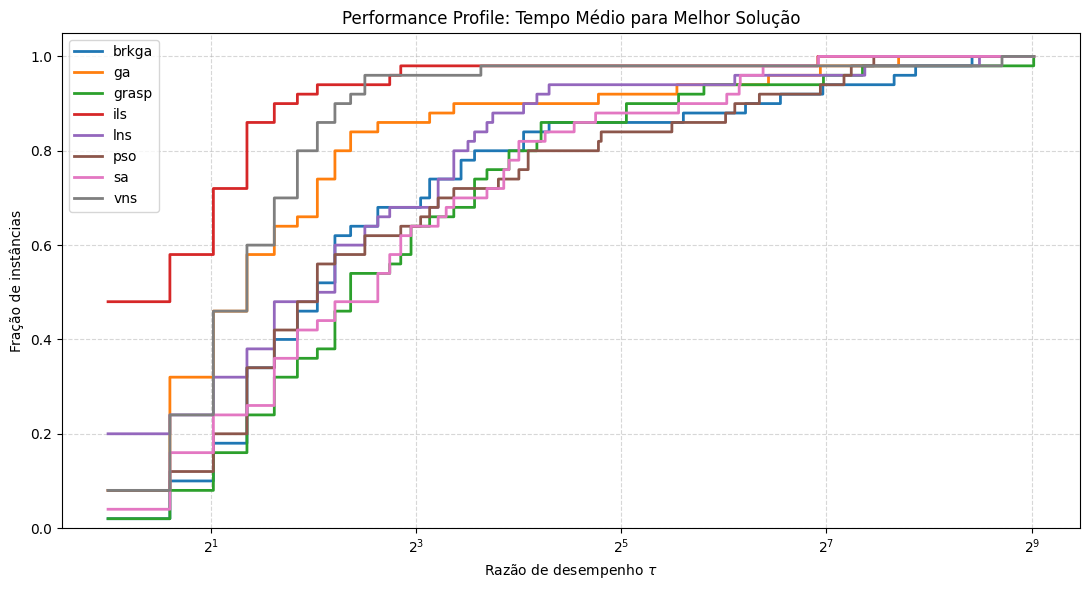

In [7]:
matriz_tempo_melhor = preparar_matriz_profile(
  df,
  metrica='tempo_melhor',
  agregacao='mean'
)

plot_performance_profile(
  matriz_tempo_melhor,
  'Performance Profile: Tempo Médio para Melhor Solução'
)

# **Teste de Friedman**

In [8]:
import itertools
import numpy as np
import pandas as pd
from scipy.stats import friedmanchisquare, wilcoxon

def preparar_matriz_teste(df, metrica, agregacao='mean', nivel='instancia'):
  df = df.copy()

  df.columns = df.columns.str.strip()
  df['instancia'] = df['instancia'].astype(str).str.strip()
  df['algo'] = df['algo'].astype(str).str.strip()

  df[metrica] = pd.to_numeric(df[metrica], errors='coerce')

  if nivel == 'instancia':
      index_cols = ['instancia']
      group_cols = ['instancia', 'algo']

  elif nivel == 'instancia_seed':
      index_cols = ['instancia', 'seed']
      group_cols = ['instancia', 'seed', 'algo']

  else:
      raise ValueError("nivel deve ser 'instancia' ou 'instancia_seed'.")

  df_agg = (
      df.groupby(group_cols)
        .agg(valor=(metrica, agregacao))
        .reset_index()
  )

  matriz = df_agg.pivot(
      index=index_cols,
      columns='algo',
      values='valor'
  )

  matriz = matriz.dropna()

  return matriz

In [9]:
def teste_friedman(df, metrica, agregacao='mean', nivel='instancia'):
  matriz = preparar_matriz_teste(
      df,
      metrica=metrica,
      agregacao=agregacao,
      nivel=nivel
  )

  algoritmos = list(matriz.columns)

  dados_por_algoritmo = [
      matriz[algo].values
      for algo in algoritmos
  ]

  stat, p_valor = friedmanchisquare(*dados_por_algoritmo)

  rankings = matriz.rank(axis=1, ascending=True, method='average')

  rankings_medios = (
      rankings.mean()
      .reset_index()
  )

  rankings_medios.columns = [
      'algo',
      'ranking_medio'
  ]

  rankings_medios = rankings_medios.sort_values(
      by='ranking_medio'
  ).reset_index(drop=True)

  resumo = pd.DataFrame([{
      'metrica': metrica,
      'agregacao': agregacao,
      'nivel': nivel,
      'n_blocos': matriz.shape[0],
      'n_algoritmos': matriz.shape[1],
      'estatistica_friedman': stat,
      'p_valor': p_valor,
      'significativo_5%': p_valor < 0.05
  }])

  return resumo, rankings_medios, matriz

In [10]:
friedman_gap, ranking_gap, matriz_gap = teste_friedman(
  df,
  metrica='gap',
  agregacao='mean',
  nivel='instancia'
)

display(friedman_gap)
display(ranking_gap)

,metrica,agregacao,nivel,n_blocos,n_algoritmos,estatistica_friedman,p_valor,significativo_5%
0,gap,mean,instancia,50,8,63.943478,2.451232e-11,True


,algo,ranking_medio
0,vns,3.83
1,ils,3.92
2,ga,3.96
3,lns,4.32
4,brkga,4.55
5,grasp,4.85
6,sa,5.12
7,pso,5.45


In [11]:
friedman_tempo_melhor, ranking_tempo_melhor, matriz_tempo_melhor = teste_friedman(
    df,
    metrica='tempo_melhor',
    agregacao='mean',
    nivel='instancia'
)

display(friedman_tempo_melhor)
display(ranking_tempo_melhor)

,metrica,agregacao,nivel,n_blocos,n_algoritmos,estatistica_friedman,p_valor,significativo_5%
0,tempo_melhor,mean,instancia,50,8,95.566667,8.859492e-18,True


,algo,ranking_medio
0,ils,2.18
1,ga,3.50
2,vns,3.70
3,lns,4.66
4,brkga,5.14
5,pso,5.20
6,sa,5.60
7,grasp,6.02


# **Teste de Wilcoxon**

In [12]:
def preparar_matriz_wilcoxon(df, metrica, agregacao='mean'):
  df = df.copy()

  df.columns = df.columns.str.strip()
  df['instancia'] = df['instancia'].astype(str).str.strip()
  df['algo'] = df['algo'].astype(str).str.strip()
  df[metrica] = pd.to_numeric(df[metrica], errors='coerce')

  df_agg = (
      df.groupby(['instancia', 'algo'])
        .agg(valor=(metrica, agregacao))
        .reset_index()
  )

  matriz = df_agg.pivot(
      index='instancia',
      columns='algo',
      values='valor'
  )

  matriz = matriz.dropna()

  return matriz

In [13]:
def teste_wilcoxon_completo(df, metrica, agregacao='mean', alpha=0.05):
  matriz = preparar_matriz_wilcoxon(df=df, metrica=metrica, agregacao=agregacao)
  algoritmos = list(matriz.columns)
  resultados = []

  for algo_a, algo_b in itertools.combinations(algoritmos, 2):
      v_a = matriz[algo_a].values
      v_b = matriz[algo_b].values

      wins_a = np.sum(v_a < v_b)
      wins_b = np.sum(v_b < v_a)
      empates = np.sum(v_a == v_b)

      try:
          _, p_valor = wilcoxon(v_a, v_b, alternative='two-sided', zero_method='wilcox')
      except ValueError:
          p_valor = 1.0

      sig = p_valor < alpha

      if sig:
          m_a, m_b = np.mean(v_a), np.mean(v_b)
          melhor = algo_a if m_a < m_b else algo_b
          veredito = f'{melhor} é superior'
      else:
          melhor = 'Empate'
          veredito = 'Equivalentes'

      resultados.append({
          'Comparação': f'{algo_a} vs {algo_b}',
          'Vitórias A': wins_a,
          'Vitórias B': wins_b,
          'Empates': empates,
          'p-valor': round(p_valor, 4),
          'Significativo?': 'Sim' if sig else 'Não',
          'Melhor': melhor
      })

  resultado_df = pd.DataFrame(resultados)
  return resultado_df, matriz

In [14]:
wilcoxon_gap, matriz_gap = teste_wilcoxon_completo(
  df,
  metrica='gap',
  agregacao='mean'
)

display(wilcoxon_gap)

,Comparação,Vitórias A,Vitórias B,Empates,p-valor,Significativo?,Melhor
0,brkga vs ga,1,12,37,0.0071,Sim,ga
1,brkga vs grasp,12,5,33,0.1024,Não,Empate
2,brkga vs ils,2,13,35,0.0076,Sim,ils
3,brkga vs lns,8,9,33,0.5228,Não,Empate
4,brkga vs pso,16,2,32,0.0006,Sim,brkga
5,brkga vs sa,12,6,32,0.1221,Não,Empate
6,brkga vs vns,3,12,35,0.0064,Sim,vns
7,ga vs grasp,13,2,35,0.0125,Sim,ga
8,ga vs ils,4,3,43,0.7353,Não,Empate
9,ga vs lns,9,4,37,0.2787,Não,Empate


In [15]:
wilcoxon_tempo_melhor, matriz_tempo_melhor = teste_wilcoxon_completo(
  df,
  metrica='tempo_melhor',
  agregacao='mean'
)

display(wilcoxon_tempo_melhor)

,Comparação,Vitórias A,Vitórias B,Empates,p-valor,Significativo?,Melhor
0,brkga vs ga,6,44,0,0.0000,Sim,ga
1,brkga vs grasp,32,18,0,0.0005,Sim,brkga
2,brkga vs ils,6,44,0,0.0000,Sim,ils
3,brkga vs lns,26,24,0,0.5086,Não,Empate
4,brkga vs pso,30,20,0,0.0005,Sim,brkga
5,brkga vs sa,30,20,0,0.0001,Sim,brkga
6,brkga vs vns,13,37,0,0.0115,Sim,vns
7,ga vs grasp,37,13,0,0.0000,Sim,ga
8,ga vs ils,16,34,0,0.1053,Não,Empate
9,ga vs lns,33,17,0,0.0024,Sim,ga


In [16]:
wilcoxon_gap.to_csv(
  'wilcoxon_gap_medio.csv',
  index=False,
  sep=';',
  encoding='utf-8-sig'
)

wilcoxon_tempo_melhor.to_csv(
  'wilcoxon_tempo_melhor_medio.csv',
  index=False,
  sep=';',
  encoding='utf-8-sig'
)

# **Time-to-Target**

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_GAP = 0.0
TOLERANCIA = 1e-9

METRICA_TEMPO = 'tempo_melhor'

USAR_ESCALA_LOG = False

def preparar_dados_ttt(df, target_gap=0.0, tolerancia=1e-9):
  dados = df.copy()

  dados.columns = dados.columns.str.strip()

  dados['instancia'] = dados['instancia'].astype(str).str.strip()
  dados['algo'] = dados['algo'].astype(str).str.strip()

  dados['gap'] = pd.to_numeric(dados['gap'], errors='coerce')
  dados['tempo_melhor'] = pd.to_numeric(dados['tempo_melhor'], errors='coerce')
  dados['tempo_total'] = pd.to_numeric(dados['tempo_total'], errors='coerce')

  dados['atingiu_target'] = dados['gap'] <= target_gap + tolerancia

  dados['ttt'] = np.where(
      dados['atingiu_target'],
      dados['tempo_melhor'],
      np.nan
  )

  return dados

In [18]:
def construir_curvas_ttt(df_ttt):
  linhas = []

  for algo in sorted(df_ttt['algo'].unique()):
      dados_algo = df_ttt[df_ttt['algo'] == algo]

      total_execucoes = len(dados_algo)

      tempos_sucesso = (
          dados_algo.loc[dados_algo['atingiu_target'], 'ttt']
          .dropna()
          .sort_values()
          .values
      )

      for i, tempo in enumerate(tempos_sucesso, start=1):
          prob = i / total_execucoes

          linhas.append({
              'algo': algo,
              'tempo': tempo,
              'prob': prob,
              'total_execucoes': total_execucoes,
              'sucessos': len(tempos_sucesso)
          })

  return pd.DataFrame(linhas)

In [19]:
def resumo_ttt(df_ttt):
  resumo = (
      df_ttt.groupby('algo')
      .agg(
          execucoes=('gap', 'count'),
          sucessos=('atingiu_target', 'sum'),
          taxa_sucesso=('atingiu_target', lambda x: 100 * x.mean()),

          ttt_mean=('ttt', 'mean'),
          ttt_std=('ttt', 'std'),
          ttt_median=('ttt', 'median'),
          ttt_min=('ttt', 'min'),
          ttt_max=('ttt', 'max'),

          tempo_total_mean=('tempo_total', 'mean')
      )
      .reset_index()
      .sort_values(
          by=['taxa_sucesso', 'ttt_median'],
          ascending=[False, True]
      )
  )

  return resumo.round(4)

In [20]:
def plot_time_to_target(curvas_ttt, titulo='Time-to-Target (TTT) Plot', escala_log=False):
  sns.set_theme(style="whitegrid")

  plt.figure(figsize=(10, 6))

  for algo in sorted(curvas_ttt['algo'].unique()):
      dados_algo = curvas_ttt[curvas_ttt['algo'] == algo]

      if dados_algo.empty:
          continue

      plt.plot(
          pd.to_numeric(dados_algo['tempo'], errors='coerce'),
          pd.to_numeric(dados_algo['prob'], errors='coerce'),
          label=algo.upper(),
          linewidth=2,
          drawstyle='steps-post'
      )

  plt.title(titulo, fontsize=14, fontweight='bold', pad=15)
  plt.xlabel('Tempo de execução em segundos', fontsize=12)
  plt.ylabel('Probabilidade acumulada', fontsize=12)

  if escala_log:
      plt.xscale('log')
      plt.xlabel('Tempo de execução em segundos, escala log', fontsize=12)

  plt.ylim(-0.02, 1.05)
  plt.legend(
      title='Meta-heurística',
      fontsize=10,
      title_fontsize=11,
      loc='lower right'
  )

  plt.tight_layout()
  plt.show()

,algo,execucoes,sucessos,taxa_sucesso,ttt_mean,ttt_std,ttt_median,ttt_min,ttt_max,tempo_total_mean
7,vns,1500,1448,96.5333,21.7644,56.5151,0.7207,0.0006,398.533,34.8767
3,ils,1500,1446,96.4000,16.9597,49.0295,0.3619,0.0004,389.346,30.7492
1,ga,1500,1429,95.2667,15.3148,41.2527,0.7076,0.0078,390.060,33.5442
0,brkga,1500,1368,91.2000,26.0368,59.5087,0.7672,0.0739,399.548,59.0458
4,lns,1500,1347,89.8000,23.6484,65.4231,0.6807,0.0002,397.027,62.0363
2,grasp,1500,1245,83.0000,33.1945,74.5902,0.7183,0.0005,397.478,95.5523
6,sa,1500,1225,81.6667,34.7597,74.6163,0.7249,0.0006,399.593,101.7211
5,pso,1500,1097,73.1333,23.5935,63.8716,0.3353,0.0008,398.428,124.7755


,algo,tempo,prob,total_execucoes,sucessos
0,brkga,0.073911,0.000667,1500,1368
1,brkga,0.075027,0.001333,1500,1368
2,brkga,0.075396,0.002000,1500,1368
3,brkga,0.076684,0.002667,1500,1368
4,brkga,0.076862,0.003333,1500,1368


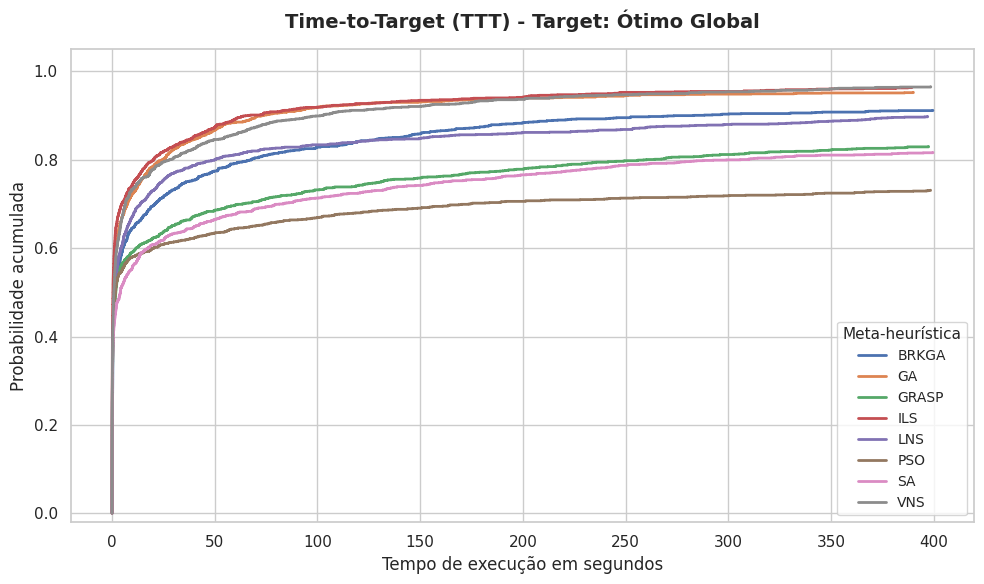

In [21]:
df_ttt = preparar_dados_ttt(
  df,
  target_gap=TARGET_GAP,
  tolerancia=TOLERANCIA
)

curvas_ttt = construir_curvas_ttt(df_ttt)

resumo = resumo_ttt(df_ttt)

display(resumo)
display(curvas_ttt.head())

plot_time_to_target(
  curvas_ttt,
  titulo='Time-to-Target (TTT) - Target: Ótimo Global',
  escala_log=USAR_ESCALA_LOG
)